In [1]:
import warnings
warnings.filterwarnings('ignore')

In [15]:
import pandas as pd
import pandas as pd
#df = pd.read_excel(file_path, sheet_name=sheet_name)
df0 = pd.read_excel("/content/sample_data/Book L8 data treatment and transform st.xlsx", "Customers")
print(f"shape {df0.shape} .... \n{df0.head()}")

shape (200, 14) .... 
    CustID  Gender      Race  BirthDate College  HouseholdSize  ZipCode  \
0  1530016  Female     Black 1986-12-16     Yes              5    90047   
1  1531136    Male     White 1993-05-09     Yes              5    90026   
2  1532160    Male     Black 1966-05-22     Yes              2    90027   
3  1532307    Male     White 1964-09-16     Yes              4    90029   
4  1532356  Female  Hispanic 1964-07-15      No              5    90017   

   Income  Spending2020  Spending2021  NumOfOrders  DaysSinceLast  \
0   53000           287           241            3            101   
1   94000          1227           843           12            262   
2   64000           523           719            9            122   
3   60000           516           582           13            129   
4   47000           555           845            7             97   

        Satisfaction Channel  
0  Very Dissatisfied      SM  
1            Neutral      TV  
2     Very Satisfie

In [34]:
df = df0.copy()

1. Subsetting data

In [17]:
#Select only rows within specified ranges of dates (on or after 1/1/1982 and before 1/1/2000.

import pandas as pd
# Convert the 'Date of Birth' column to datetime objects (Just in case)
#df['BirthDate'] = pd.to_datetime(df['BirthDate'])

# Filter the DataFrame
start_date = pd.to_datetime('1982-01-01')
end_date = pd.to_datetime('2000-01-01')
filtered_df = df[(df['BirthDate'] >= start_date) & (df['BirthDate'] < end_date)]

print(f"shape {filtered_df.shape} .... \n{filtered_df.head()}")


shape (74, 14) .... 
     CustID  Gender      Race  BirthDate College  HouseholdSize  ZipCode  \
0   1530016  Female     Black 1986-12-16     Yes              5    90047   
1   1531136    Male     White 1993-05-09     Yes              5    90026   
6   1533017  Female  Hispanic 1985-05-14     Yes              3    90063   
10  1533791    Male     White 1999-10-27     Yes              1    90060   
11  1533917  Female     Black 1993-03-03     Yes              3    90045   

    Income  Spending2020  Spending2021  NumOfOrders  DaysSinceLast  \
0    53000           287           241            3            101   
1    94000          1227           843           12            262   
6    84000           229           153            2            144   
10   97000           828          1028           17            110   
11   64000           768           915           15             19   

         Satisfaction   Channel  
0   Very Dissatisfied        SM  
1             Neutral        TV  

In [18]:
df.columns #Show column names

Index(['CustID', 'Gender', 'Race', 'BirthDate', 'College', 'HouseholdSize',
       'ZipCode', 'Income', 'Spending2020', 'Spending2021', 'NumOfOrders',
       'DaysSinceLast', 'Satisfaction', 'Channel'],
      dtype='object')

In [20]:
# Select specific columns
selected_columns = ['Gender', 'HouseholdSize', 'Income', 'Spending2021', 'NumOfOrders', 'Channel']  # Replace with your desired column names
new_df = filtered_df[selected_columns]

print(f"shape {new_df.shape} .... \n{new_df.head()}")


shape (74, 6) .... 
    Gender  HouseholdSize  Income  Spending2021  NumOfOrders   Channel
0   Female              5   53000           241            3        SM
1     Male              5   94000           843           12        TV
6   Female              3   84000           153            2       Web
10    Male              1   97000          1028           17       Web
11  Female              3   64000           915           15  Referral


In [22]:
#Split df using Gender column into tables of male and female
male_df = new_df[new_df['Gender'] == 'Male']
female_df = new_df[new_df['Gender'] == 'Female']
print(f"shape {male_df.shape} .... \n{male_df.head()}")
print(f"shape {female_df.shape} .... \n{female_df.head()}")

shape (49, 6) .... 
   Gender  HouseholdSize  Income  Spending2021  NumOfOrders   Channel
1    Male              5   94000           843           12        TV
10   Male              1   97000          1028           17       Web
12   Male              2  114000           665            7        TV
15   Male              5   55000           100            1       Web
22   Male              2   94000           524            7  Referral
shape (25, 6) .... 
    Gender  HouseholdSize  Income  Spending2021  NumOfOrders   Channel
0   Female              5   53000           241            3        SM
6   Female              3   84000           153            2       Web
11  Female              3   64000           915           15  Referral
14  Female              3   42000           313            4        TV
50  Female              5   97000           911           16       Web


2. Transforming categorical data (reduction)

In [23]:
df = df0.copy()
#Filter and show only unique values in Race column of df and count of each unique va
unique_races = df['Race'].unique()
print("Unique values in 'Race' column:")
print(unique_races)

race_counts = df['Race'].value_counts()
print("\nCount of each unique value in 'Race' column:")
race_counts


Unique values in 'Race' column:
['Black' 'White' 'Hispanic' 'Asian' 'Pacific Islander' 'American Indian']

Count of each unique value in 'Race' column:


,count
Race,
White,79
Black,57
Hispanic,41
Asian,15
American Indian,5
Pacific Islander,3


In [29]:
#Combine the race with counts <= 5 into new labels of "Others"

# Combine races with counts <= 5 into "Others"
threshold = 5
races_to_combine = race_counts[race_counts <= threshold].index
df['Race'] = df['Race'].replace(races_to_combine, 'Others')

# Verify the changes
race_counts = df['Race'].value_counts()
print("\nCount of each unique value in 'Race' column after combining:")
race_counts



Count of each unique value in 'Race' column after combining:


,count
Race,
White,79
Black,57
Hispanic,41
Asian,15
American Indian,5
Pacific Islander,3


3. Transforming Categories into Numeric (Dummy encoding)

In [41]:
#Transform Channel column into dummy encoding of binary values, reference category = "Web".
import pandas as pd
df = df0.copy()
# One-hot encode without dropping any category
df[dummies] = pd.get_dummies(df['Channel'], drop_first=False)
print(df)

reference_category = 'Web'
Channel_dummies = dummies.drop(columns=[reference_category])

# Display the updated DataFrame
print(df.head())


      CustID  Gender             Race  BirthDate College  HouseholdSize  \
0    1530016  Female            Black 1986-12-16     Yes              5   
1    1531136    Male            White 1993-05-09     Yes              5   
2    1532160    Male            Black 1966-05-22     Yes              2   
3    1532307    Male            White 1964-09-16     Yes              4   
4    1532356  Female         Hispanic 1964-07-15      No              5   
..       ...     ...              ...        ...     ...            ...   
195  1578525    Male         Hispanic 1963-12-12     Yes              1   
196  1579349    Male            Asian 1980-12-19     Yes              1   
197  1579389  Female  American Indian 2000-05-21     Yes              1   
198  1579857  Female            White 1991-01-26     Yes              1   
199  1579979    Male            White 1999-07-05     Yes              5   

     ZipCode  Income  Spending2020  Spending2021  NumOfOrders  DaysSinceLast  \
0      90047   5300

In [55]:
df = df0.copy()

In [50]:
#Transform column Channel to dummy encoding, reference_category = 'Web'

import pandas as pd
# Assuming 'df' is your DataFrame and it has a 'Channel' column

# Create dummy variables for the 'Channel' column without dropping any
dummies = pd.get_dummies(df['Channel'], prefix='Channel', drop_first=False)
print(f"One-Hot encoding: \n{dummies}")

# Add the dummy variables to the DataFrame
df = pd.concat([df, dummies.astype(int)], axis=1) #Convert logical value into Integer

# Specify the reference category
reference_category = 'Web'

# Remove the reference category column
df = df.drop(columns=['Channel_' + reference_category])

# Display the updated DataFrame
print(df.head())


One-Hot encoding: 
     Channel_Referral  Channel_SM  Channel_TV  Channel_Web
0               False        True       False        False
1               False       False        True        False
2               False       False        True        False
3               False        True       False        False
4               False       False       False         True
..                ...         ...         ...          ...
195             False       False       False         True
196             False       False       False         True
197              True       False       False        False
198              True       False       False        False
199             False        True       False        False

[200 rows x 4 columns]
    CustID  Gender      Race  BirthDate College  HouseholdSize  ZipCode  \
0  1530016  Female     Black 1986-12-16     Yes              5    90047   
1  1531136    Male     White 1993-05-09     Yes              5    90026   
2  1532160    Male     B

4. Transform categorical data into Numeric (Satisfaction scores)

In [62]:
#Transform categorical values in Satisfaction into integer scales of 1-5.

# Create a mapping for satisfaction levels to numerical scores
satisfaction_mapping = {
    'Very Satisfied': 5,
    'Somewhat Satisfied': 4,
    'Neutral': 3,
    'Somewhat Dissatisfied': 2,
    'Very Dissatisfied': 1
}

# Apply the mapping to the 'Satisfaction' column
df['Satisfaction_Score'] = df['Satisfaction'].map(satisfaction_mapping)

# Display the updated DataFrame
print(df[['Satisfaction', 'Satisfaction_Score']].head())
print(f"\n\nfrequency of each score... {df['Satisfaction_Score'].value_counts()}")


        Satisfaction  Satisfaction_Score
0  Very Dissatisfied                   1
1            Neutral                   3
2     Very Satisfied                   5
3  Very Dissatisfied                   1
4  Very Dissatisfied                   1


frequency of each score... Satisfaction_Score
4    94
5    45
3    35
2    17
1     9
Name: count, dtype: int64


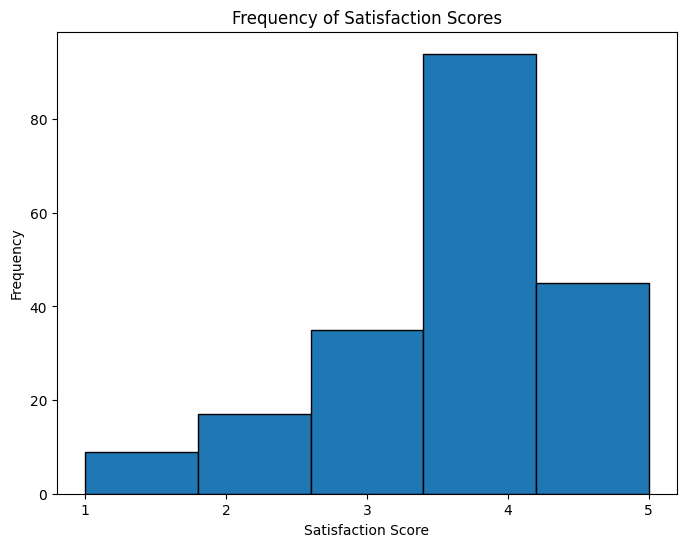

In [63]:
#Plot frequency of satisfaction scores histogram

import matplotlib.pyplot as plt

# Create the histogram
plt.figure(figsize=(8, 6))  # Adjust figure size as needed
plt.hist(df['Satisfaction_Score'], bins=5, edgecolor='black')  # Bins=5 for 5 satisfaction levels
plt.xlabel('Satisfaction Score')
plt.ylabel('Frequency')
plt.title('Frequency of Satisfaction Scores')
plt.xticks(range(1, 6))  # Set x-axis ticks to 1, 2, 3, 4, 5
plt.show()
